# Figure 2 — Regional disruption & recovery across the 6 mobility categories

**Target**: npj Urban Sustainability submission (Helene + Milton mobility paper).

**Four panels, generated as separate files** for external composition:
- **(a)** Helene · heatmap of within-region relative deviation (% from baseline) across days × 6 categories.
- **(b)** Milton · same.
- **(c)** Grouped bar chart of largest within-region drop per category, Helene vs Milton (with 0% reference line).
- **(d)** Grouped bar chart of trend-based recovery time (days from landing) per category, Helene vs Milton.

**Data sources** (all pre-computed in `regional_baseline.ipynb` / `regional_metrics.ipynb` — no analysis re-run):
- Per-category baselines (y_true, y_pred, CI) — `results/regional_level/{helene,milton}/baseline_within_{Category}.csv`
- Recovery metrics — `results/regional_level/regional_metrics_summary.csv`

**Outputs** (vector PDF + 300 dpi PNG for each panel) in `results/npj_figures/`:
- `figure2a_heatmap_helene.{pdf,png}`
- `figure2b_heatmap_milton.{pdf,png}`
- `figure2c_largest_drop.{pdf,png}`
- `figure2d_recovery_time.{pdf,png}`

**Notes**
- Utilities category excluded per submission scope; 6 categories used everywhere.
- Panels (a)/(b) use a 21-day window centred on landfall (landing −7 to landing +14) so the two hurricanes are directly visually comparable despite different landfall dates.
- Within-flow only here (inflow is in Figure 3 per the plan).

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.dates import DateFormatter, DayLocator

warnings.filterwarnings('ignore')

# npj Urban Sustainability print-ready formatting (matches figure1_overview.ipynb)
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [2]:
# Project path resolution (mirrors figure1_overview.ipynb)
def find_project_root(start: pathlib.Path) -> pathlib.Path:
    sentinel = pathlib.Path('results') / 'regional_level' / 'regional_metrics_summary.csv'
    for p in [start, *start.parents]:
        if (p / sentinel).exists():
            return p
    raise FileNotFoundError(
        f'Could not locate project root containing {sentinel} (started from {start}).'
    )

NOTEBOOK_DIR = pathlib.Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
RESULTS = PROJECT_ROOT / 'results'
REGIONAL = RESULTS / 'regional_level'
METRICS_CSV = REGIONAL / 'regional_metrics_summary.csv'

OUT_DIR = RESULTS / 'npj_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'REGIONAL     : exists={REGIONAL.exists()}')
print(f'METRICS_CSV  : exists={METRICS_CSV.exists()}')
print(f'OUT_DIR      : {OUT_DIR}')

PROJECT_ROOT : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category
REGIONAL     : exists=True
METRICS_CSV  : exists=True
OUT_DIR      : /Users/qing/Library/CloudStorage/OneDrive-ColumbiaUniversityIrvingMedicalCenter/4_hurricane_category/results/npj_figures


In [33]:
# Configuration (mirrors figure1_overview.ipynb where relevant)
HURRICANES = {
    'helene': {
        'label': 'Helene',
        'landing': pd.Timestamp('2024-09-26'),
        'color': '#1f77b4',
    },
    'milton': {
        'label': 'Milton',
        'landing': pd.Timestamp('2024-10-09'),
        'color': '#d62728',
    },
}

# 6 mobility categories (Utilities excluded for npj submission)
CATEGORIES = [
    'Travel',
    'Work & Professional',
    'Health',
    'Education',
    'Retail & Leisure',
    'Urban Government',
]

# Okabe-Ito colorblind-safe palette (kept consistent with Figure 1)
CATEGORY_COLORS = {
    'Travel'             : '#0072B2',
    'Work & Professional': '#E69F00',
    'Health'             : '#009E73',
    'Education'          : '#CC79A7',
    'Retail & Leisure'   : '#56B4E9',
    'Urban Government'   : '#D55E00',
}

# Heatmap window — symmetric around landfall so the two hurricanes line up visually
PRE_DAYS  = 7
POST_DAYS = 14

FLOW = 'inflow'  # Figure 2 is within-region only; Figure 3 covers the flow decomposition

def category_to_filename(cat: str) -> str:
    return cat.replace(' & ', '_and_').replace(' ', '_')

def save_panel(fig, stem):
    pdf_path = OUT_DIR / f'{stem}.pdf'
    png_path = OUT_DIR / f'{stem}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, dpi=300, bbox_inches='tight')
    print(f'  saved \u2192 {pdf_path.relative_to(PROJECT_ROOT)}')
    print(f'  saved \u2192 {png_path.relative_to(PROJECT_ROOT)}')

In [34]:
# Load cached baselines and metrics — no SARIMAX re-fit
def load_relative_deviation_matrix(hkey: str, flow: str = FLOW) -> pd.DataFrame:
    """Return a (categories x days) DataFrame of % deviation from SARIMAX baseline.

    Reads the per-category cached baselines and computes:
        rd = (y_true - y_pred) / y_pred * 100
    over the [landing - PRE_DAYS, landing + POST_DAYS] window.
    """
    landing = HURRICANES[hkey]['landing']
    win_start = landing - pd.Timedelta(days=PRE_DAYS)
    win_end   = landing + pd.Timedelta(days=POST_DAYS)

    rows = {}
    for cat in CATEGORIES:
        cat_safe = category_to_filename(cat)
        path = REGIONAL / hkey / f'baseline_{flow}_{cat_safe}.csv'
        bl = pd.read_csv(path, index_col=0, parse_dates=True)
        bl = bl.loc[win_start:win_end]
        rd = (bl['y_true'] - bl['y_pred']) / bl['y_pred'] * 100.0
        rows[cat] = rd

    rd_df = pd.DataFrame(rows).T  # categories x dates
    rd_df.columns.name = 'date'
    rd_df.index.name = 'category'
    return rd_df

RD = {h: load_relative_deviation_matrix(h) for h in HURRICANES}
for h, df in RD.items():
    print(f'{h:7s}  shape={df.shape}  range=[{df.values.min():+.1f}%, {df.values.max():+.1f}%]')

METRICS = pd.read_csv(METRICS_CSV)
METRICS = METRICS[METRICS['category'].isin(CATEGORIES)].copy()
print(f'metrics rows kept (6 categories): {len(METRICS)}')
METRICS.head()

helene   shape=(6, 21)  range=[-21.5%, +22.1%]
milton   shape=(6, 21)  range=[-71.1%, +25.2%]
metrics rows kept (6 categories): 36


,hurricane,flow_type,category,largest_drop,drop_date,largest_increase,increase_date,recovery_days,recovery_date,trough_date,slope_pct_per_day,total_disruption
0,milton,within,Travel,-48.623165,2024-10-10,15.278041,2024-10-07,4.826926,2024-10-13 19:50:46.401452813,2024-10-10,739.009566,234.700414
1,milton,within,Work & Professional,-37.233281,2024-10-09,16.108812,2024-10-07,4.788430,2024-10-13 18:55:20.378426848,2024-10-10,583.040727,178.288970
2,milton,within,Health,-25.112259,2024-10-10,21.308645,2024-10-06,4.549102,2024-10-13 13:10:42.393681304,2024-10-10,553.499832,114.238223
3,milton,within,Education,-34.954414,2024-10-11,10.600196,2024-10-06,6.310886,2024-10-15 07:27:40.555063889,2024-10-10,553.584304,220.593323
4,milton,within,Retail & Leisure,-33.086794,2024-10-10,13.453612,2024-10-06,5.157755,2024-10-14 03:47:10.035455438,2024-10-10,571.956247,170.653581


## Panels (a) and (b) — Per-hurricane heatmaps of relative deviation

Within-region trips relative to the SARIMAX baseline, in percent. Diverging palette centred on 0; common color scale across both hurricanes so they are directly comparable. Landfall is the vertical dashed line.

shared color scale: -80% to +80%
  saved → results/npj_figures/figure2e_heatmap_helene.pdf
  saved → results/npj_figures/figure2e_heatmap_helene.png


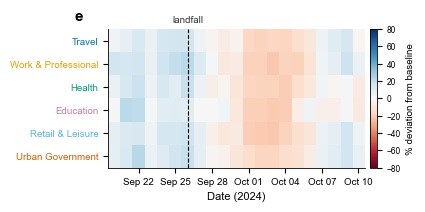

  saved → results/npj_figures/figure2f_heatmap_milton.pdf
  saved → results/npj_figures/figure2f_heatmap_milton.png


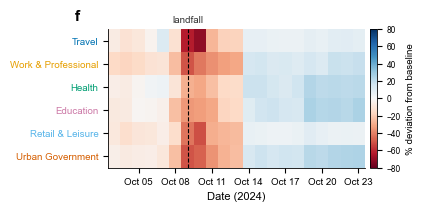

In [35]:
# Shared symmetric color scale across both hurricanes (use the joint max abs value)
joint_abs_max = max(abs(RD[h].values).max() for h in HURRICANES)
VMAX = float(np.ceil(joint_abs_max / 10.0) * 10.0)  # round up to nearest 10%
print(f'shared color scale: -{VMAX:.0f}% to +{VMAX:.0f}%')

def panel_heatmap(ax, hkey: str, panel_letter: str, *, show_cbar: bool = True):
    rd = RD[hkey]
    dates = pd.to_datetime(rd.columns)
    landing = HURRICANES[hkey]['landing']

    norm = TwoSlopeNorm(vmin=-VMAX, vcenter=0.0, vmax=VMAX)
    im = ax.imshow(
        rd.values,
        aspect='auto',
        cmap='RdBu',
        norm=norm,
        interpolation='nearest',
        extent=[mpl.dates.date2num(dates[0]) - 0.5,
                mpl.dates.date2num(dates[-1]) + 0.5,
                len(rd.index) - 0.5, -0.5],
    )
    ax.xaxis_date()

    # Landfall marker
    ax.axvline(landing, color='black', linestyle='--', linewidth=0.8)
    ymax = len(rd.index) - 0.5
    ax.text(landing, -0.7, 'landfall', ha='center', va='bottom',
            fontsize=7, color='#333')

    # Category labels with colored squares matching the categorical palette
    ax.set_yticks(range(len(rd.index)))
    ax.set_yticklabels(rd.index)
    for tick, cat in zip(ax.get_yticklabels(), rd.index):
        tick.set_color(CATEGORY_COLORS[cat])

    ax.xaxis.set_major_locator(DayLocator(interval=3))
    ax.xaxis.set_major_formatter(DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=0)
    ax.set_xlabel('Date (2024)')
    # ax.set_title(
    #     f"{HURRICANES[hkey]['label']}  \u00b7  within-region deviation from baseline",
    #     loc='left', fontsize=8, color='#333', pad=4,
    # )

    ax.text(-0.13, 1.04, panel_letter, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')

    if show_cbar:
        cbar = ax.figure.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label('% deviation from baseline', fontsize=7)
        cbar.ax.tick_params(labelsize=6)
    return im


# Render and save panel (a) — Helene
fig_a, ax_a = plt.subplots(figsize=(3.5, 1.8))
panel_heatmap(ax_a, 'helene', 'e')
save_panel(fig_a, 'figure2e_heatmap_helene')
plt.show()

# Render and save panel (b) — Milton
fig_b, ax_b = plt.subplots(figsize=(3.5, 1.8))
panel_heatmap(ax_b, 'milton', 'f')
save_panel(fig_b, 'figure2f_heatmap_milton')
plt.show()

## Panel (c) — Largest within-region drop per category

Largest negative deviation from baseline within the landing week per category, Helene (blue) vs. Milton (red). Values come straight from `regional_metrics_summary.csv` (column `largest_drop`).

hurricane            helene  milton
category                           
Travel                -12.1   -48.6
Work & Professional   -12.6   -37.2
Health                -10.0   -25.1
Education              -8.5   -35.0
Retail & Leisure      -14.6   -33.1
Urban Government      -12.7   -29.4
  saved → results/npj_figures/figure2c_largest_drop.pdf
  saved → results/npj_figures/figure2c_largest_drop.png


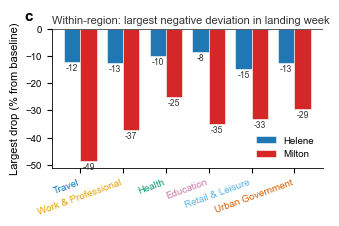

In [12]:
def metrics_pivot(metric_col: str, flow: str = FLOW) -> pd.DataFrame:
    sub = METRICS[METRICS['flow_type'] == flow]
    piv = (sub.pivot(index='category', columns='hurricane', values=metric_col)
              .reindex(CATEGORIES)
              [list(HURRICANES.keys())])  # column order: helene, milton
    return piv

def grouped_bar(ax, piv: pd.DataFrame, ylabel: str, panel_letter: str,
                *, value_fmt: str = '{:.1f}', zero_line: bool = False):
    cats = list(piv.index)
    x = np.arange(len(cats))
    width = 0.38
    offsets = {'helene': -width/2, 'milton': +width/2}

    for hkey in HURRICANES:
        vals = piv[hkey].values
        bars = ax.bar(x + offsets[hkey], vals, width,
                      color=HURRICANES[hkey]['color'],
                      edgecolor='white', linewidth=0.4,
                      label=HURRICANES[hkey]['label'])
        for rect, v in zip(bars, vals):
            if np.isnan(v):
                continue
            ax.text(rect.get_x() + rect.get_width() / 2,
                    rect.get_height() + (0.5 if v >= 0 else -0.5),
                    value_fmt.format(v),
                    ha='center',
                    va='bottom' if v >= 0 else 'top',
                    fontsize=6.2, color='#333')

    if zero_line:
        ax.axhline(0, color='#444', linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=20, ha='right')
    for tick, cat in zip(ax.get_xticklabels(), cats):
        tick.set_color(CATEGORY_COLORS[cat])
    ax.set_ylabel(ylabel)
    ax.legend(loc='best', frameon=False)
    ax.text(-0.10, 1.04, panel_letter, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='bottom', ha='left')
    return ax


drop_piv = metrics_pivot('largest_drop')
print(drop_piv.round(1))

fig_c, ax_c = plt.subplots(figsize=(3.5, 1.8))
grouped_bar(
    ax_c, drop_piv,
    ylabel='Largest drop (% from baseline)',
    panel_letter='c',
    value_fmt='{:.0f}',
    zero_line=True,
)
ax_c.set_title('Within-region: largest negative deviation in landing week',
               loc='left', fontsize=8, color='#333', pad=4)
save_panel(fig_c, 'figure2c_largest_drop')
plt.show()

## Panel (d) — Trend-based recovery time per category

Days from landfall to the Theil–Sen recovery line's zero-crossing per category, Helene (blue) vs. Milton (red). Values come straight from `regional_metrics_summary.csv` (column `recovery_days`).

hurricane            helene  milton
category                           
Travel                 4.43    4.83
Work & Professional    4.29    4.79
Health                 4.11    4.55
Education              3.01    6.31
Retail & Leisure       4.79    5.16
Urban Government       4.46    4.93
  saved → results/npj_figures/figure2d_recovery_time.pdf
  saved → results/npj_figures/figure2d_recovery_time.png


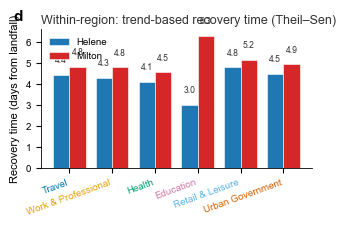

In [13]:
rec_piv = metrics_pivot('recovery_days')
print(rec_piv.round(2))

fig_d, ax_d = plt.subplots(figsize=(3.5, 1.8))
grouped_bar(
    ax_d, rec_piv,
    ylabel='Recovery time (days from landfall)',
    panel_letter='d',
    value_fmt='{:.1f}',
    zero_line=False,
)
ax_d.set_ylim(bottom=0)
ax_d.set_title('Within-region: trend-based recovery time (Theil\u2013Sen)',
               loc='left', fontsize=9, color='#333', pad=4)
save_panel(fig_d, 'figure2d_recovery_time')
plt.show()

## Caption draft (for the assembled Fig. 2)

**Fig. 2 | Regional mobility disruption and recovery across six urban-functional categories.**
**(a, b)** Daily within-region trips expressed as percent deviation from the SARIMAX counterfactual baseline for the six mobility categories (Utilities excluded) over the landfall ±2 week window. Diverging palette is centred at 0 % and shares a common scale across both hurricanes for direct visual comparison. Dashed line marks landfall (Helene 2024-09-26; Milton 2024-10-09).
**(c)** Largest negative within-region deviation within the landing week, by category. Bars show observed % deviation (Helene blue, Milton red).
**(d)** Trend-based recovery time (days from landfall) estimated from the Theil–Sen slope of the post-trough monotonic segment of relative deviation. Same colour coding.

All values are read directly from cached per-category baselines and `regional_metrics_summary.csv`; no models are re-fit by this figure notebook.